# DynaSD Quickstart

End-to-end seizure detection on a bundled synthetic example.

This notebook walks through the four steps that make up every DynaSD pipeline:

1. **Load data** — get a seizure recording.
2. **Fit** — calibrate a detector on the baseline portion.
3. **Forward** — score every window of the full recording.
4. **Threshold** - set an interictal-ictal transition boundary
5. **Annotate** — call `get_onset_and_spread` to extract per-channel onset times.

We use the closed-form `ABSSLP` detector here for speed; every detector class in
`DynaSD.__all__` (e.g. `ABSSLP`, `IMPRINT`, `NDD`, `GIN`, `LiNDDA`) follows the
same `fit` → `forward` → `get_onset_and_spread` interface.


## 1. Load the bundled example

`dynasd.load_example_seizure()` returns a synthetic 60 s recording (8 channels,
fs=256 Hz) with a polyspike seizure planted at t=30 s on the first 4 channels.
The remaining 4 channels stay baseline throughout.

In [1]:
# If DynaSD isn't installed, fall back to importing from the repo root.
import sys, pathlib
_repo = pathlib.Path.cwd().parent
if (_repo / 'dynasd').is_dir() and str(_repo) not in sys.path:
    sys.path.insert(0, str(_repo))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dynasd import ABSSLP, load_example_seizure 
from dynasd.tools.viz import plot_ieeg_data,set_plot_params

set_plot_params()

example = load_example_seizure()
X = example.signal              # pd.DataFrame, shape (n_samples, n_channels)
fs = example.fs                 # 256 Hz
sz_start = example.seizure_start_sec   # 30.0
sz_end = example.seizure_end_sec       # 60.0
focal = example.focal_channels         # ['Ch01', 'Ch02', 'Ch03', 'Ch04']

print(f"signal: {X.shape}  fs={fs}  duration={len(X)/fs:.1f}s")
print(f"planted seizure: {sz_start}-{sz_end}s on {focal}")

signal: (15360, 8)  fs=256  duration=60.0s
planted seizure: 30.0-60.0s on ['Ch01', 'Ch02', 'Ch03', 'Ch04']


Quick look at the raw signal — focal channels in red, baseline in black.

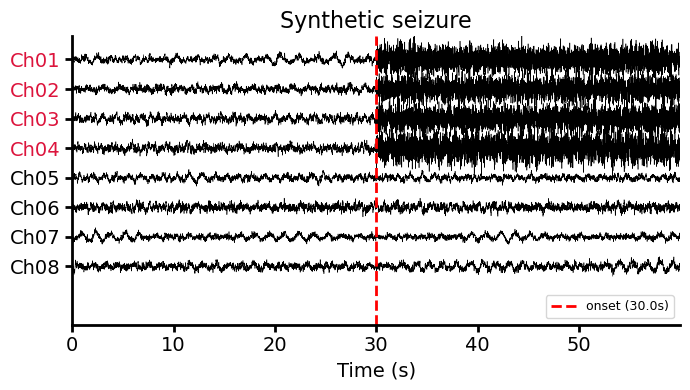

In [2]:
fig,ax = plot_ieeg_data(X, fs=fs, colors=["crimson" if ch in focal else "black" for ch in X.columns],
               fig_size=(7, 4))

ax.axvline(sz_start, color="red", ls="--", lw=2, label=f"onset ({sz_start}s)")

ax.set_yticklabels(X.columns)
ax.set_xlabel("Time (s)")
ax.set_title("Synthetic seizure")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()

## 2. Fit the detector on the baseline

Detectors learn per-channel reference statistics from a stretch of baseline data with
a preictal buffer. Pass only the baseline portion to `fit`.

In [3]:
baseline = X.iloc[: int((sz_start - 10) * fs)]   # first 20 seconds

model = ABSSLP(fs=fs, w_size=1.0, w_stride=0.5)
model.fit(baseline)
print(f"model fitted: {model.is_fitted}")

model fitted: True


## 3. Forward-pass the full recording

`model(X)` returns a `pd.DataFrame` of per-window detector scores. The
row index is the window-start time in seconds (named ``t_sec``); columns match
the input channel names.

In [4]:
sz_prob = model(X)
print(f"sz_prob: {sz_prob.shape}  index name='{sz_prob.index.name}'")
sz_prob.head()

sz_prob: (119, 8)  index name='t_sec'


,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07,Ch08
t_sec,,,,,,,,
0.0,57.551151,81.553496,72.059465,73.036786,62.844381,89.093503,57.382239,83.916681
0.5,62.017974,80.238103,71.563450,74.413591,62.853952,94.103125,56.635699,76.439121
1.0,58.450614,74.209567,68.420338,71.993593,66.988319,88.725317,55.523569,76.976017
1.5,55.462461,74.260960,66.963666,76.707645,67.400013,93.104536,54.611725,77.762788
2.0,60.334657,75.865787,67.440122,76.924193,62.420623,96.537728,54.340658,79.513610


## 4. Visualize the detector output

`sz_prob` is the per-window detector score per channel

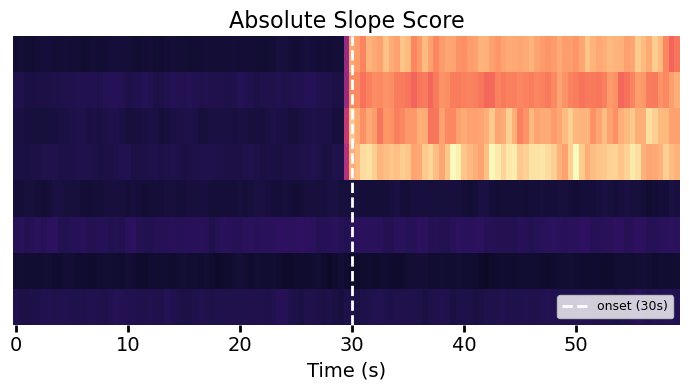

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

# Plot the score matrix
ax.imshow(sz_prob.T, vmin=0, vmax=600, aspect='auto', cmap='magma')

# Remove all axis spines for clean publication-ready appearance
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove tick marks for clean visualization
ax.set_yticks([])
ax.set_xticks(range(0,len(sz_prob.index),20), sz_prob.index.astype(int)[::20])
ax.set_xlabel("Time (s)")
ax.set_title("Absolute Slope Score")
onset_idx = np.where(sz_prob.index == sz_start)[0][0]
ax.axvline(onset_idx, color="white", ls="--", lw=2, label=f"onset ({int(sz_start)}s)")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()

## 5. Annotate onset and spread

`get_onset_and_spread` smooths the per-window scores, thresholds them, and
applies a sustained-activity criterion to extract per-channel seizure onset
times.

**Key parameters** (all in seconds):
- `threshold` — score above which a window counts as seizing.
- `filter_w` — smoothing window length (uniform filter on the score).
- `rwin_size` — lookahead span for the spread criterion.
- `rwin_req` — required active duration within `rwin_size` to flag onset.

The defaults (`filter_w=10s, rwin_size=5s, rwin_req=4s`) work well; set the `threshold` based on our pretrained values or from your own data. For ABSSLP on this fixture,`threshold=300.0` separates baseline from seizure cleanly.

Note the slight drift in onset time due to the window requirements (rwin). Setting rwin_size = rwin_req = w_size removes the majority seizing window requirements. 

In [6]:
# Get a pretrianed threshold from our corpus of annotated seizure onsets
model.get_threshold(method = 'pretrained', threshold_agg = 'mean')

# model.threshold = 300.0 # You can also manually set the threshold

onsets, sz_clf = model.get_onset_and_spread(
    sz_prob,
    # threshold=300.0, # Can also set threshold in get_onset_and_spread call
    filter_w=10.0, # Moving mean filter on feature
    rwin_size=5.0,
    rwin_req=4.0,
    ret_smooth_mat=True, # Return the thresholded output
)

# If you want to remove the window requirements, set rwin_size = rwin_req = w_size
# onsets, sz_clf = model.get_onset_and_spread(
#     sz_prob,
#     filter_w=10.0,
#     rwin_size=1.0,
#     rwin_req=1.0,
#     ret_smooth_mat=True,
# )

# ``onsets`` is a single-row DataFrame: per-channel onset time in seconds
# (NaN for channels that never reach sustained activity).
onsets.T.rename(columns={0: "onset_sec"})

,onset_sec
Ch04,28.5
Ch01,29.0
Ch03,29.0
Ch02,29.5
Ch05,NaN
Ch06,NaN
Ch07,NaN
Ch08,NaN


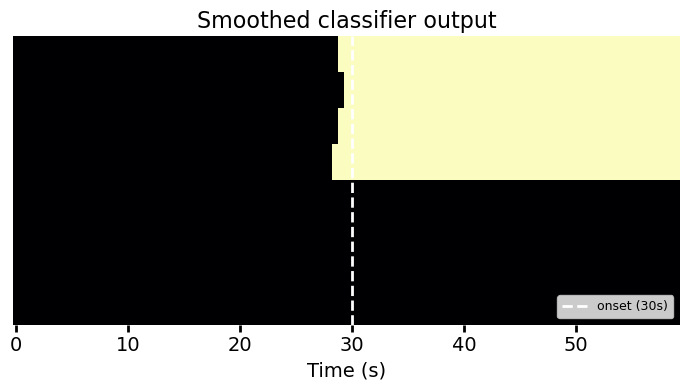

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

# Plot the score matrix
ax.imshow(sz_clf.T, vmin=0, vmax=1, aspect='auto', cmap='magma')

# Plot onset time
onset_idx = np.where(sz_clf.index == sz_start)[0][0]
ax.axvline(onset_idx, color="white", ls="--", lw=2, label=f"onset ({int(sz_start)}s)")

# Remove all axis spines for appearance
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove tick marks for clean visualization
ax.set_yticks([])
ax.set_xticks(range(0,len(sz_clf.index),20), sz_clf.index.astype(int)[::20])
ax.set_xlabel("Time (s)")
ax.set_title("Smoothed classifier output")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()

## 6. Annotated seizure boundary

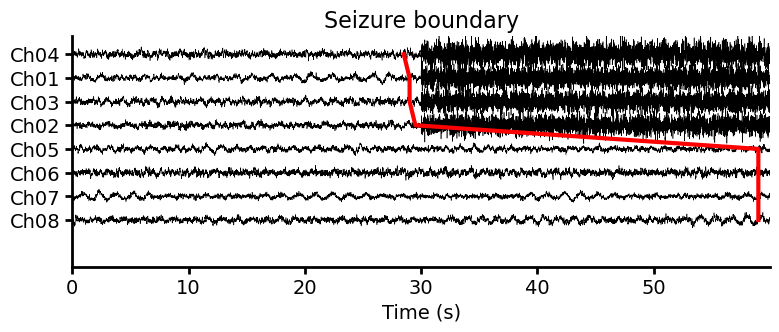

In [8]:
# Plot the seizure sorted by onset time
fig, ax = plot_ieeg_data(X.loc[:, onsets.columns],
                         fs,
                         fig_size=(9, 3),
                         empty=False)  

seizure_times = onsets.copy()
yticks = ax.get_yticks()

# Here we set non-seizing channels to the last timepoint in the recording for visualization purposes
seizure_times.fillna(sz_prob.index[-1], inplace=True)

# Plot wavefront progression as white line connecting seizure onset times
ax.plot(seizure_times.values.flatten(), yticks, color='red', linewidth=3)
ax.set_title("Seizure boundary")
plt.show()